# Cluster 3 — desempenho e tempo: diário vs. horário, LSTM vs. LazyPredict

Compara os 4 braços do experimento isolado (`experiments/cluster3_hourly_vs_daily/`),
todos restritos ao Cluster 3, 100% dos dados, mesmos slices oficiais de
treino/val/teste:

- **LSTM diário** — `ClusterPreprocessor`+`ClusterTrainer`, arm `basin`.
- **LSTM horário** — mesmo `ClusterTrainer`, dataset ERA5 horário novo.
- **LazyPredict diário** — `cluster_lazy.run()` (produção), mesmo arm `basin`.
- **LazyPredict horário** — LazyPredict com as 12 variáveis horárias
  agregadas (mean/max/min/std sobre os 7 dias anteriores).

Lê `metrics.csv`/`timing.json` dos 4 diretórios reais do run no Modal e
reconstrói a configuração de cada braço a partir do próprio código do
experimento — nenhum número ou lista de features abaixo é digitado à mão.

**Nota metodológica**: a primeira versão deste experimento comparava os
braços horários usando só as 12 variáveis brutas do dataset novo, enquanto
os braços diários usavam ~56 features (incluindo lags do alvo, sazonalidade
cíclica, climatologia e contexto regional `_basin`) — um confounding entre
"granularidade" e "quantidade de engenharia de feature", não uma comparação
isolada de resolução temporal. Os dois braços horários foram refeitos
(`experiments/cluster3_hourly_vs_daily/engineered_features.py`) somando as
mesmas features de lag/sazonalidade/climatologia do braço diário (calculadas
sobre a série diária resample do dado horário) — a diferença remanescente
entre diário e horário abaixo reflete melhor o efeito real da granularidade.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Markdown, display

sys.path.insert(0, "..")

ARTIFACTS_ROOT = Path("../artifacts/experiments/cluster3_hourly_vs_daily")
ARM_NAMES = ["daily", "hourly", "daily_lazy", "hourly_lazy"]
ARM_LABELS = {
    "daily": "LSTM diário", "hourly": "LSTM horário",
    "daily_lazy": "Lazy diário", "hourly_lazy": "Lazy horário",
}
COLORS = {
    "daily": "#1f77b4", "hourly": "#ff7f0e",
    "daily_lazy": "#2ca02c", "hourly_lazy": "#d62728",
}
SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

# _download_artifacts (src/modal/cluster_lstm.py) preserva o caminho relativo
# completo do volume Modal, o que às vezes duplica o prefixo "experiments/
# cluster3_hourly_vs_daily/" dentro do próprio ARTIFACTS_ROOT — procura os
# dois layouts possíveis em vez de assumir um fixo.
def _find_arm_dir(arm: str) -> Path:
    candidates = [
        ARTIFACTS_ROOT / arm,
        ARTIFACTS_ROOT / "experiments" / "cluster3_hourly_vs_daily" / arm,
    ]
    for c in candidates:
        if (c / "metrics.csv").exists():
            return c
    raise FileNotFoundError(f"Não achei metrics.csv do braço '{arm}' em {candidates}")

ARM_DIRS = {arm: _find_arm_dir(arm) for arm in ARM_NAMES}
print(ARM_DIRS)

{'daily': PosixPath('../artifacts/experiments/cluster3_hourly_vs_daily/experiments/cluster3_hourly_vs_daily/daily'), 'hourly': PosixPath('../artifacts/experiments/cluster3_hourly_vs_daily/hourly'), 'daily_lazy': PosixPath('../artifacts/experiments/cluster3_hourly_vs_daily/daily_lazy'), 'hourly_lazy': PosixPath('../artifacts/experiments/cluster3_hourly_vs_daily/hourly_lazy')}


## Carregar métricas e timing dos 4 braços

In [2]:
metrics_parts = []
timing = {}
for arm, d in ARM_DIRS.items():
    m = pd.read_csv(d / "metrics.csv")
    m["arm"] = arm
    m["cluster_id"] = m["cluster_id"].astype(str)
    metrics_parts.append(m)
    timing[arm] = json.loads((d / "timing.json").read_text())

metrics = pd.concat(metrics_parts, ignore_index=True)
metrics["season"] = pd.Categorical(metrics["season"], categories=["ALL"] + SEASON_ORDER, ordered=True)
metrics = metrics.sort_values(["season", "arm"]).reset_index(drop=True)
metrics[["arm", "season", "n_samples", "R2", "RMSE", "Bias_P90", "RMSE_P90", "Corr"] + (["model"] if "model" in metrics.columns else [])]

,arm,season,n_samples,R2,RMSE,Bias_P90,RMSE_P90,Corr,model
0,daily_lazy,ALL,11462,0.608058,2.241558,-3.166067,4.621700,0.780,CatBoostRegressor
1,hourly_lazy,ALL,12770,0.589500,2.280000,-3.361000,4.875000,0.769,LGBMRegressor
2,daily,DJF,3184,0.281200,2.763000,-3.232000,5.727000,0.594,NaN
3,daily_lazy,DJF,2745,0.379214,2.602108,-4.138546,5.540417,0.616,ExtraTreesRegressor
4,hourly,DJF,3719,0.232400,2.823000,-3.361000,5.724000,0.562,NaN
5,hourly_lazy,DJF,3099,0.340800,2.662000,-4.347000,5.701000,0.586,SGDRegressor
6,daily,MAM,3177,0.590100,2.214000,-1.575000,4.068000,0.791,NaN
7,daily_lazy,MAM,2925,0.643755,2.075766,-3.222315,4.374918,0.805,GradientBoostingRegressor
8,hourly,MAM,3836,0.550600,2.273000,-1.353000,4.121000,0.777,NaN
9,hourly_lazy,MAM,3480,0.644500,2.034000,-2.860000,4.155000,0.803,Ridge


## Qual pipeline/modelo cada braço rodou, e quais features

Reconstrói a configuração real de cada braço a partir do próprio código do
experimento (`experiments/cluster3_hourly_vs_daily/`) e dos `timing.json` do
run real — não de uma descrição escrita à mão.

In [3]:
from src.data.cluster_assigner import assign_station_clusters
from src.pipelines.common import resolve_feature_groups
from experiments.cluster3_hourly_vs_daily.run_experiment import LSTM_PARAMS
from experiments.cluster3_hourly_vs_daily.hourly_windower import (
    HOURLY_FEATURES, TARGET_CLUSTER,
)
from experiments.cluster3_hourly_vs_daily.hourly_flat_features import flat_feature_columns

# LSTM diário: mesma reconstrução de feature_names que ClusterPreprocessor.run()
# faz (resolve_feature_groups + one-hot de cluster), sem recarregar os ~7GB de
# dados pesados — só os metadados de estação/cluster, que são leves.
daily_base_features = resolve_feature_groups("original,era5_basin")
ds_inmet_meta = xr.open_dataset("../dataset/raw/INMET_Stratified.nc")
station_clusters = assign_station_clusters(ds_inmet_meta, "../dataset/shp")
cluster_ids = sorted(station_clusters["cluster_id"].unique().tolist())
daily_cluster_cols = [f"cluster_{c}" for c in cluster_ids]
daily_feature_names = daily_base_features + daily_cluster_cols
hourly_feature_names = HOURLY_FEATURES + [f"cluster_{TARGET_CLUSTER}"]
hourly_lazy_features = flat_feature_columns()

pipeline_md = f"""
| | LSTM diário | LSTM horário | Lazy diário | Lazy horário |
|---|---|---|---|---|
| Pipeline | `ClusterPreprocessor`+`ClusterTrainer` | `ClusterTrainer` + windower próprio | `cluster_lazy.run()` (produção) | LazyPredict + agregador horário próprio |
| Fonte de dados | arm `basin` (`original,era5_basin`) | ERA5 horário novo (`test_cluster_3_hourly.nc`) | arm `basin` (`original,era5_basin`) | mesmas 12 vars horárias, agregadas |
| Lookback / janela | {timing['daily']['lookback']} dias | {timing['hourly']['lookback']}h ({timing['hourly']['lookback']//24} dias) | 1 dia (flat) | mean/max/min/std sobre 7 dias |
| Nº de features | {timing['daily']['n_features']} | {timing['hourly']['n_features']} | {timing['daily_lazy']['n_features']} | {timing['hourly_lazy']['n_features']} |
| Modelos avaliados | 1 (LSTM dual-head) | 1 (LSTM dual-head) | ~{timing['daily_lazy']['train_params']['n_regressors_screened']} (LazyPredict) | ~{timing['hourly_lazy']['train_params']['n_regressors_screened']} (LazyPredict) |
| Hiperparâmetros | `{LSTM_PARAMS}` | idênticos ao diário | `RANDOM_STATE`/`_FAST_REGRESSORS` de `cluster_lazy.py` | idênticos ao Lazy diário |

**Features LSTM diário** ({len(daily_base_features)} + {len(daily_cluster_cols)} one-hot de cluster):
`{daily_base_features}`

**Features LSTM horário** ({len(HOURLY_FEATURES)} + 1 one-hot de cluster): `{hourly_feature_names}`

**Features Lazy horário** ({len(hourly_lazy_features)}, 12 vars × 4 agregações + gust_P50): `{hourly_lazy_features}`
"""
display(Markdown(pipeline_md))


| | LSTM diário | LSTM horário | Lazy diário | Lazy horário |
|---|---|---|---|---|
| Pipeline | `ClusterPreprocessor`+`ClusterTrainer` | `ClusterTrainer` + windower próprio | `cluster_lazy.run()` (produção) | LazyPredict + agregador horário próprio |
| Fonte de dados | arm `basin` (`original,era5_basin`) | ERA5 horário novo (`test_cluster_3_hourly.nc`) | arm `basin` (`original,era5_basin`) | mesmas 12 vars horárias, agregadas |
| Lookback / janela | 7 dias | 168h (7 dias) | 1 dia (flat) | mean/max/min/std sobre 7 dias |
| Nº de features | 70 | 30 | 57 | 66 |
| Modelos avaliados | 1 (LSTM dual-head) | 1 (LSTM dual-head) | ~39 (LazyPredict) | ~39 (LazyPredict) |
| Hiperparâmetros | `{'units': 64, 'dropout': 0.4, 'l2_reg': 0.01, 'learning_rate': 0.001, 'weight_normal': 0.7, 'weight_extreme': 0.3, 'extreme_weight': 20.0, 'extreme_threshold': 1.5}` | idênticos ao diário | `RANDOM_STATE`/`_FAST_REGRESSORS` de `cluster_lazy.py` | idênticos ao Lazy diário |

**Features LSTM diário** (56 + 14 one-hot de cluster):
`['10m_u_component_of_wind', '10m_v_component_of_wind', 'wind_mag', 'wind_mag_max', 'wind_mag_std', 'wind_dir_sin', 'wind_dir_cos', 'gust_factor', 'lag1_wind_mag_max', 'lag2_wind_mag_max', 'lag3_wind_mag_max', 'lag7_wind_mag_max', 'rolling7d_wind_mag_max', '2m_temperature', '2m_dewpoint_temperature', 'relative_humidity', 't2m_range', 'surface_pressure', 'pressure_tendency', 'total_precipitation', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'era5_clim_wind', 'latitude', 'longitude', 'lag1_gust_obs', 'lag2_gust_obs', 'lag3_gust_obs', 'rolling7d_gust_obs', 'wind_mag_max_anom', 'rolling3d_wind_mag_max', 'lag1_pressure_tendency', 'ws_p90_basin', 'msl_min_basin', 'msl_range_basin', 't2m_max_basin', 't2m_min_basin', 'rh_p10_basin', 'tp_max_basin', 'tp_lag1_basin', 'tp_lag2_basin', 'tp_roll3_basin', 'ws_mean_basin', 'ws_max_basin', 'ws_std_basin', 'sin_dir_mean_basin', 'cos_dir_mean_basin', 'msl_mean_basin', 'd_msl_basin', 't2m_mean_basin', 't2m_range_basin', 'rh_mean_basin', 'td_dep_mean_basin', 'tp_sum_basin']`

**Features LSTM horário** (12 + 1 one-hot de cluster): `['ws_h', 'wd_h', 'sin_dir_h', 'cos_dir_h', 'msl_h', 't2m_h', 'rh_h', 'td_dep_h', 'tp_h', 'tp_roll24h', 'tp_roll48h', 'tp_roll72h', 'cluster_3']`

**Features Lazy horário** (66, 12 vars × 4 agregações + gust_P50): `['ws_h_mean', 'ws_h_max', 'ws_h_min', 'ws_h_std', 'wd_h_mean', 'wd_h_max', 'wd_h_min', 'wd_h_std', 'sin_dir_h_mean', 'sin_dir_h_max', 'sin_dir_h_min', 'sin_dir_h_std', 'cos_dir_h_mean', 'cos_dir_h_max', 'cos_dir_h_min', 'cos_dir_h_std', 'msl_h_mean', 'msl_h_max', 'msl_h_min', 'msl_h_std', 't2m_h_mean', 't2m_h_max', 't2m_h_min', 't2m_h_std', 'rh_h_mean', 'rh_h_max', 'rh_h_min', 'rh_h_std', 'td_dep_h_mean', 'td_dep_h_max', 'td_dep_h_min', 'td_dep_h_std', 'tp_h_mean', 'tp_h_max', 'tp_h_min', 'tp_h_std', 'tp_roll24h_mean', 'tp_roll24h_max', 'tp_roll24h_min', 'tp_roll24h_std', 'tp_roll48h_mean', 'tp_roll48h_max', 'tp_roll48h_min', 'tp_roll48h_std', 'tp_roll72h_mean', 'tp_roll72h_max', 'tp_roll72h_min', 'tp_roll72h_std', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'era5_clim_wind', 'lag1_era5_proxy', 'lag2_era5_proxy', 'lag3_era5_proxy', 'lag7_era5_proxy', 'rolling7d_era5_proxy', 'rolling3d_era5_proxy', 'era5_proxy_anom', 'gust_factor', 'lag1_gust_obs', 'lag2_gust_obs', 'lag3_gust_obs', 'rolling7d_gust_obs', 'gust_P50']`


## Qual modelo o LazyPredict escolheu, por trimestre

In [4]:
model_choice = (
    metrics[metrics["arm"].isin(["daily_lazy", "hourly_lazy"])]
    .pivot(index="season", columns="arm", values="model")
    .reindex(["ALL"] + SEASON_ORDER)
    .rename(columns=ARM_LABELS)
)
model_choice

arm,Lazy diário,Lazy horário
season,,
ALL,CatBoostRegressor,LGBMRegressor
DJF,ExtraTreesRegressor,SGDRegressor
MAM,GradientBoostingRegressor,Ridge
JJA,CatBoostRegressor,LassoLarsCV
SON,ExtraTreesRegressor,LarsCV


## Desempenho isolado por trimestre

Cada trimestre lado a lado, com todas as métricas dos 4 braços.

In [5]:
display_cols = ["n_samples", "R2", "RMSE", "Bias", "Bias_P90", "RMSE_P90", "Corr"]
season_metrics = metrics[metrics["season"] != "ALL"]
pivot = season_metrics.pivot(index="season", columns="arm", values=display_cols).reindex(SEASON_ORDER)
pivot.columns = [f"{metric} ({ARM_LABELS[arm]})" for metric, arm in pivot.columns]
pivot

,n_samples (LSTM diário),n_samples (Lazy diário),n_samples (LSTM horário),n_samples (Lazy horário),R2 (LSTM diário),R2 (Lazy diário),R2 (LSTM horário),R2 (Lazy horário),RMSE (LSTM diário),RMSE (Lazy diário),...,Bias_P90 (LSTM horário),Bias_P90 (Lazy horário),RMSE_P90 (LSTM diário),RMSE_P90 (Lazy diário),RMSE_P90 (LSTM horário),RMSE_P90 (Lazy horário),Corr (LSTM diário),Corr (Lazy diário),Corr (LSTM horário),Corr (Lazy horário)
season,,,,,,,,,,,,,,,,,,,,,
DJF,3184.0,2745.0,3719.0,3099.0,0.2812,0.379214,0.2324,0.3408,2.763,2.602108,...,-3.361,-4.347,5.727,5.540417,5.724,5.701,0.594,0.616,0.562,0.586
MAM,3177.0,2925.0,3836.0,3480.0,0.5901,0.643755,0.5506,0.6445,2.214,2.075766,...,-1.353,-2.860,4.068,4.374918,4.121,4.155,0.791,0.805,0.777,0.803
JJA,3113.0,2929.0,3476.0,3217.0,0.6393,0.704232,0.5894,0.6650,2.286,2.090338,...,-1.561,-3.266,4.628,4.403130,4.669,4.855,0.812,0.840,0.795,0.817
SON,3045.0,2863.0,3473.0,2974.0,0.5101,0.582487,0.4413,0.5342,2.420,2.240108,...,-2.293,-4.085,4.931,4.633413,4.775,5.308,0.742,0.764,0.715,0.743


In [6]:
for season in SEASON_ORDER:
    sub = season_metrics[season_metrics["season"] == season].set_index("arm")
    lines = [f"### {season}", ""]
    for metric in ["n_samples", "R2", "RMSE", "Bias", "Bias_P90", "RMSE_P90", "Corr"]:
        vals = {arm: sub.loc[arm, metric] for arm in ARM_NAMES if arm in sub.index}
        parts = "  |  ".join(f"{ARM_LABELS[arm]}={v}" for arm, v in vals.items())
        lines.append(f"- **{metric}**: {parts}")
    display(Markdown("\n".join(lines)))

### DJF

- **n_samples**: LSTM diário=3184  |  LSTM horário=3719  |  Lazy diário=2745  |  Lazy horário=3099
- **R2**: LSTM diário=0.2812  |  LSTM horário=0.2324  |  Lazy diário=0.3792137475539466  |  Lazy horário=0.3408
- **RMSE**: LSTM diário=2.763  |  LSTM horário=2.823  |  Lazy diário=2.602107750807485  |  Lazy horário=2.662
- **Bias**: LSTM diário=0.183  |  LSTM horário=0.33  |  Lazy diário=0.0514790528233145  |  Lazy horário=0.149
- **Bias_P90**: LSTM diário=-3.232  |  LSTM horário=-3.361  |  Lazy diário=-4.138546428571429  |  Lazy horário=-4.347
- **RMSE_P90**: LSTM diário=5.727  |  LSTM horário=5.724  |  Lazy diário=5.540417064948399  |  Lazy horário=5.701
- **Corr**: LSTM diário=0.594  |  LSTM horário=0.562  |  Lazy diário=0.616  |  Lazy horário=0.586

### MAM

- **n_samples**: LSTM diário=3177  |  LSTM horário=3836  |  Lazy diário=2925  |  Lazy horário=3480
- **R2**: LSTM diário=0.5901  |  LSTM horário=0.5506  |  Lazy diário=0.6437553299443901  |  Lazy horário=0.6445
- **RMSE**: LSTM diário=2.214  |  LSTM horário=2.273  |  Lazy diário=2.075765511549299  |  Lazy horário=2.034
- **Bias**: LSTM diário=0.039  |  LSTM horário=0.358  |  Lazy diário=-0.1382859771921787  |  Lazy horário=-0.045
- **Bias_P90**: LSTM diário=-1.575  |  LSTM horário=-1.353  |  Lazy diário=-3.222314706613601  |  Lazy horário=-2.86
- **RMSE_P90**: LSTM diário=4.068  |  LSTM horário=4.121  |  Lazy diário=4.374918266504563  |  Lazy horário=4.155
- **Corr**: LSTM diário=0.791  |  LSTM horário=0.777  |  Lazy diário=0.805  |  Lazy horário=0.803

### JJA

- **n_samples**: LSTM diário=3113  |  LSTM horário=3476  |  Lazy diário=2929  |  Lazy horário=3217
- **R2**: LSTM diário=0.6393  |  LSTM horário=0.5894  |  Lazy diário=0.7042318007212895  |  Lazy horário=0.665
- **RMSE**: LSTM diário=2.286  |  LSTM horário=2.428  |  Lazy diário=2.090337560409025  |  Lazy horário=2.216
- **Bias**: LSTM diário=-0.134  |  LSTM horário=0.324  |  Lazy diário=-0.023144830881632  |  Lazy horário=0.008
- **Bias_P90**: LSTM diário=-2.013  |  LSTM horário=-1.561  |  Lazy diário=-3.016582177431763  |  Lazy horário=-3.266
- **RMSE_P90**: LSTM diário=4.628  |  LSTM horário=4.669  |  Lazy diário=4.403129744986877  |  Lazy horário=4.855
- **Corr**: LSTM diário=0.812  |  LSTM horário=0.795  |  Lazy diário=0.84  |  Lazy horário=0.817

### SON

- **n_samples**: LSTM diário=3045  |  LSTM horário=3473  |  Lazy diário=2863  |  Lazy horário=2974
- **R2**: LSTM diário=0.5101  |  LSTM horário=0.4413  |  Lazy diário=0.5824870633349626  |  Lazy horário=0.5342
- **RMSE**: LSTM diário=2.42  |  LSTM horário=2.555  |  Lazy diário=2.240107929186553  |  Lazy horário=2.373
- **Bias**: LSTM diário=0.007  |  LSTM horário=0.423  |  Lazy diário=0.1539102340202578  |  Lazy horário=0.191
- **Bias_P90**: LSTM diário=-2.538  |  LSTM horário=-2.293  |  Lazy diário=-3.289764505119455  |  Lazy horário=-4.085
- **RMSE_P90**: LSTM diário=4.931  |  LSTM horário=4.775  |  Lazy diário=4.633413067998911  |  Lazy horário=5.308
- **Corr**: LSTM diário=0.742  |  LSTM horário=0.715  |  Lazy diário=0.764  |  Lazy horário=0.743

## Desempenho por trimestre — R² e RMSE (visual)

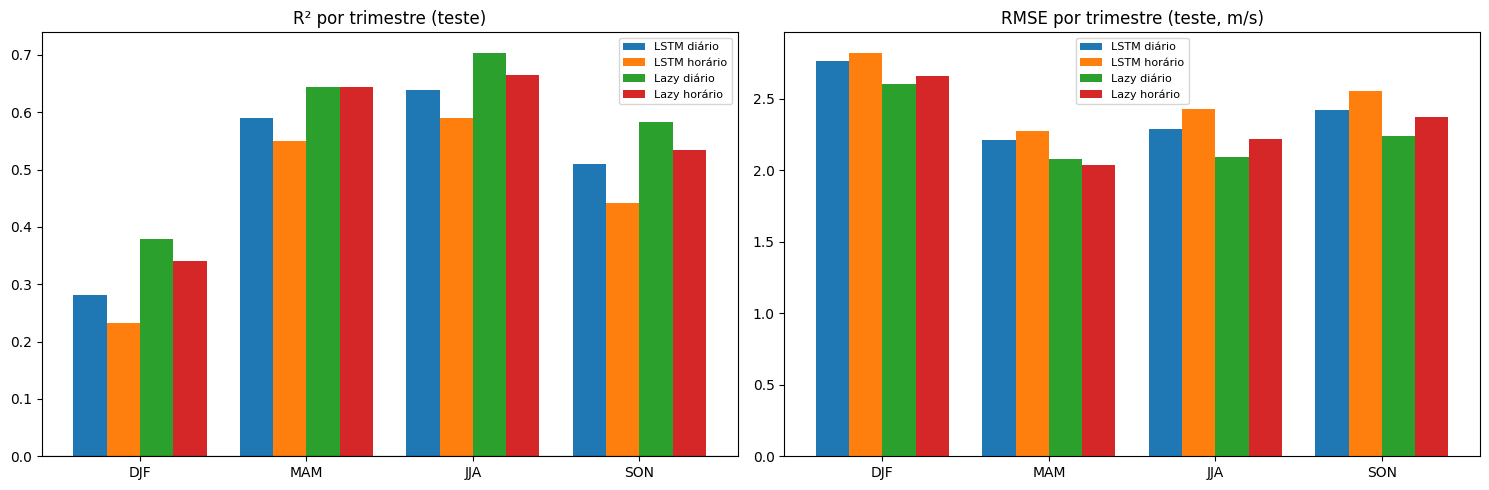

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(SEASON_ORDER))
n_arms = len(ARM_NAMES)
width = 0.8 / n_arms

for i, arm in enumerate(ARM_NAMES):
    sub = season_metrics[season_metrics["arm"] == arm].set_index("season").reindex(SEASON_ORDER)
    offset = (i - (n_arms - 1) / 2) * width
    axes[0].bar(x + offset, sub["R2"], width, label=ARM_LABELS[arm], color=COLORS[arm])
    axes[1].bar(x + offset, sub["RMSE"], width, label=ARM_LABELS[arm], color=COLORS[arm])

axes[0].set_title("R² por trimestre (teste)")
axes[0].set_xticks(x); axes[0].set_xticklabels(SEASON_ORDER)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend(fontsize=8)

axes[1].set_title("RMSE por trimestre (teste, m/s)")
axes[1].set_xticks(x); axes[1].set_xticklabels(SEASON_ORDER)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Melhor R² por trimestre — LSTM vs. Lazy, diário vs. horário

Dois painéis lado a lado: dado diário (LSTM diário vs. Lazy diário) e dado
horário (LSTM horário vs. Lazy horário) — a estrela marca o modelo vencedor
em cada trimestre, dentro de cada dataset.

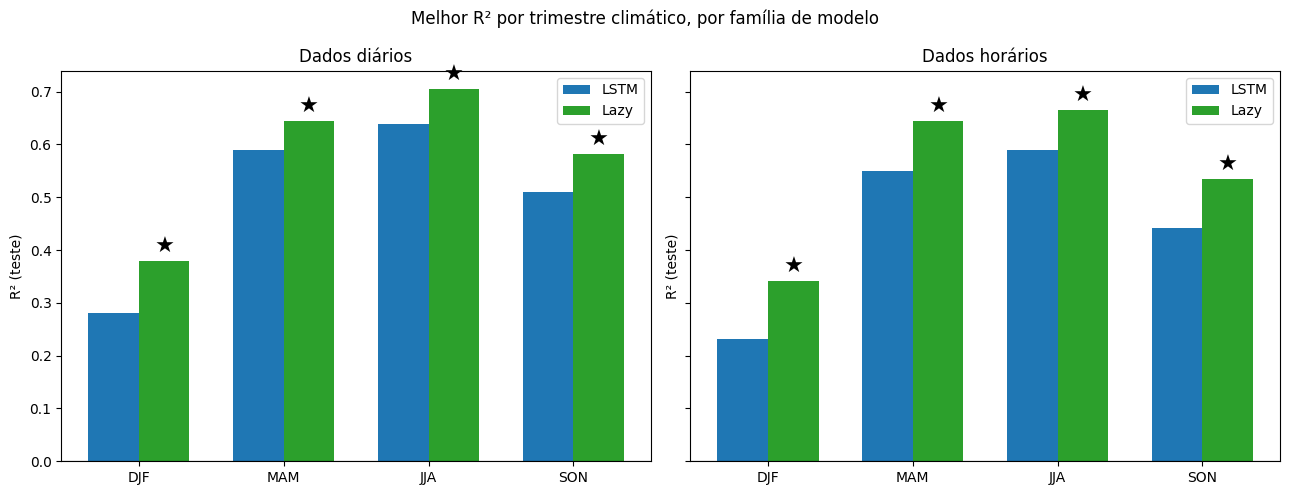

,dataset,season,LSTM,Lazy,melhor_modelo,melhor_R2
0,Dados diários,DJF,0.2812,0.3792,Lazy,0.3792
1,Dados diários,MAM,0.5901,0.6438,Lazy,0.6438
2,Dados diários,JJA,0.6393,0.7042,Lazy,0.7042
3,Dados diários,SON,0.5101,0.5825,Lazy,0.5825
4,Dados horários,DJF,0.2324,0.3408,Lazy,0.3408
5,Dados horários,MAM,0.5506,0.6445,Lazy,0.6445
6,Dados horários,JJA,0.5894,0.6650,Lazy,0.6650
7,Dados horários,SON,0.4413,0.5342,Lazy,0.5342


In [8]:
dataset_groups = {
    "Dados diários": {"LSTM": "daily", "Lazy": "daily_lazy"},
    "Dados horários": {"LSTM": "hourly", "Lazy": "hourly_lazy"},
}
model_colors = {"LSTM": "#1f77b4", "Lazy": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
width = 0.35
winners_rows = []

for ax, (title, group) in zip(axes, dataset_groups.items()):
    r2_by_model = {}
    for i, (model_label, arm) in enumerate(group.items()):
        sub = season_metrics[season_metrics["arm"] == arm].set_index("season").reindex(SEASON_ORDER)
        offset = (i - (len(group) - 1) / 2) * width
        ax.bar(x + offset, sub["R2"], width, label=model_label, color=model_colors[model_label])
        r2_by_model[model_label] = sub["R2"]

    r2_table = pd.DataFrame(r2_by_model)
    best_model_per_season = r2_table.idxmax(axis=1)
    for j, season in enumerate(SEASON_ORDER):
        best_model = best_model_per_season[season]
        best_r2 = r2_table.loc[season, best_model]
        model_idx = list(group.keys()).index(best_model)
        offset = (model_idx - (len(group) - 1) / 2) * width
        ax.annotate(
            "\u2605", (j + offset, best_r2), ha="center", va="bottom",
            fontsize=16, xytext=(0, 3), textcoords="offset points",
        )
        winners_rows.append({
            "dataset": title, "season": season,
            **{m: round(v, 4) for m, v in r2_table.loc[season].items()},
            "melhor_modelo": best_model, "melhor_R2": round(best_r2, 4),
        })

    ax.set_title(title)
    ax.set_xticks(x); ax.set_xticklabels(SEASON_ORDER)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("R² (teste)")
    ax.legend()

plt.suptitle("Melhor R² por trimestre climático, por família de modelo")
plt.tight_layout()
plt.show()

pd.DataFrame(winners_rows)

## Cauda extrema — Bias_P90 e RMSE_P90

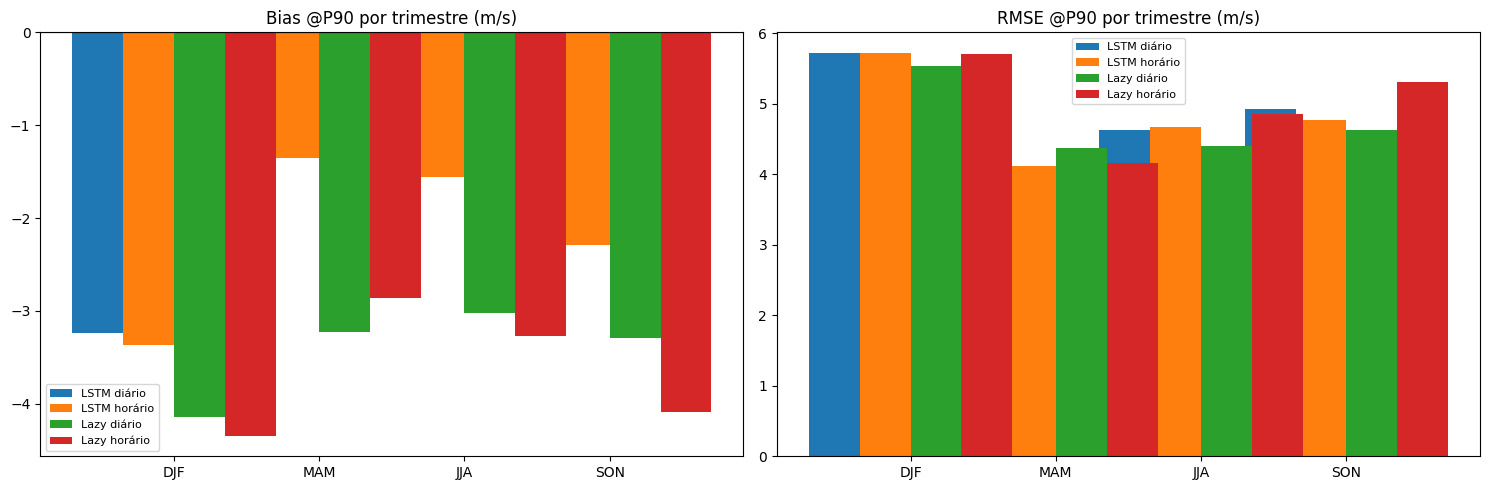

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, arm in enumerate(ARM_NAMES):
    sub = season_metrics[season_metrics["arm"] == arm].set_index("season").reindex(SEASON_ORDER)
    offset = (i - (n_arms - 1) / 2) * width
    axes[0].bar(x + offset, sub["Bias_P90"], width, label=ARM_LABELS[arm], color=COLORS[arm])
    axes[1].bar(x + offset, sub["RMSE_P90"], width, label=ARM_LABELS[arm], color=COLORS[arm])

axes[0].set_title("Bias @P90 por trimestre (m/s)")
axes[0].set_xticks(x); axes[0].set_xticklabels(SEASON_ORDER)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend(fontsize=8)

axes[1].set_title("RMSE @P90 por trimestre (m/s)")
axes[1].set_xticks(x); axes[1].set_xticklabels(SEASON_ORDER)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Tempo de treino/screening

In [10]:
timing_df = pd.DataFrame([
    {
        "arm": arm,
        "label": ARM_LABELS[arm],
        "tempo_s": t["elapsed_seconds"],
        "n_features": t.get("n_features"),
        "lookback": t.get("lookback"),
    }
    for arm, t in timing.items()
])
timing_df

,arm,label,tempo_s,n_features,lookback
0,daily,LSTM diário,44.569283,70,7.0
1,hourly,LSTM horário,45.537161,30,168.0
2,daily_lazy,Lazy diário,332.637936,57,NaN
3,hourly_lazy,Lazy horário,754.806091,66,NaN


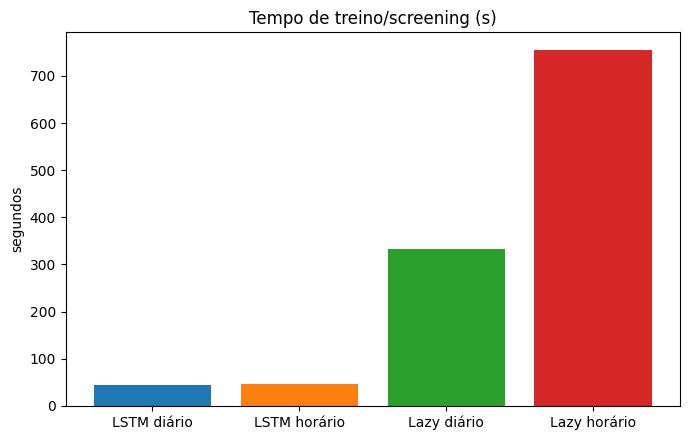

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(timing_df["label"], timing_df["tempo_s"], color=[COLORS[a] for a in timing_df["arm"]])
ax.set_title("Tempo de treino/screening (s)")
ax.set_ylabel("segundos")
plt.tight_layout()
plt.show()

## Resumo calculado

In [12]:
avg_r2 = season_metrics.groupby("arm")["R2"].mean().reindex(ARM_NAMES)
avg_rmse = season_metrics.groupby("arm")["RMSE"].mean().reindex(ARM_NAMES)
elapsed = pd.Series({arm: t["elapsed_seconds"] for arm, t in timing.items()}).reindex(ARM_NAMES)

best_arm = avg_r2.idxmax()

summary_rows = "\n".join(
    f"| {ARM_LABELS[arm]} | {avg_r2[arm]:.3f} | {avg_rmse[arm]:.3f} | {elapsed[arm]:.1f} |"
    for arm in ARM_NAMES
)

hourly_vs_daily_lstm = avg_r2["hourly"] - avg_r2["daily"]
hourly_vs_daily_lazy = avg_r2["hourly_lazy"] - avg_r2["daily_lazy"]
lazy_vs_lstm_daily = avg_r2["daily_lazy"] - avg_r2["daily"]

resumo_md = f"""
| Braço | R² médio (4 trimestres) | RMSE médio (m/s) | Tempo (s) |
|---|---|---|---|
{summary_rows}

**Melhor braço geral**: {ARM_LABELS[best_arm]} (R² médio {avg_r2[best_arm]:.3f}).

**Efeito do dado horário**: no LSTM, ΔR²={hourly_vs_daily_lstm:+.3f}
({"melhora" if hourly_vs_daily_lstm > 0 else "piora"}); no LazyPredict,
ΔR²={hourly_vs_daily_lazy:+.3f}
({"melhora" if hourly_vs_daily_lazy > 0 else "piora"}) — {"o dado horário ajuda nas duas famílias de modelo." if hourly_vs_daily_lstm > 0 and hourly_vs_daily_lazy > 0 else "o dado horário não ajuda de forma consistente entre as famílias de modelo." if (hourly_vs_daily_lstm > 0) != (hourly_vs_daily_lazy > 0) else "o dado horário piora nas duas famílias de modelo."}

**LazyPredict vs. LSTM no dado diário**: ΔR²={lazy_vs_lstm_daily:+.3f}
({"LazyPredict supera o LSTM" if lazy_vs_lstm_daily > 0 else "LSTM supera o LazyPredict"}) — mesmo arm de features (`basin`), Cluster 3.
"""
display(Markdown(resumo_md))


| Braço | R² médio (4 trimestres) | RMSE médio (m/s) | Tempo (s) |
|---|---|---|---|
| LSTM diário | 0.505 | 2.421 | 44.6 |
| LSTM horário | 0.453 | 2.520 | 45.5 |
| Lazy diário | 0.577 | 2.252 | 332.6 |
| Lazy horário | 0.546 | 2.321 | 754.8 |

**Melhor braço geral**: Lazy diário (R² médio 0.577).

**Efeito do dado horário**: no LSTM, ΔR²=-0.052
(piora); no LazyPredict,
ΔR²=-0.031
(piora) — o dado horário piora nas duas famílias de modelo.

**LazyPredict vs. LSTM no dado diário**: ΔR²=+0.072
(LazyPredict supera o LSTM) — mesmo arm de features (`basin`), Cluster 3.
